# ResNet Ablation Study

ResNet의 핵심 아이디어인 **Skip Connection(잔차 연결)** 의 효과를 검증하는 실험입니다.  
ResNet과 PlainNet(skip connection 없는 버전)을 직접 구현하고 성능을 비교합니다.

---

## 실험 구성

| 모델 | 블록 타입 | Skip Connection |
|------|-----------|----------------|
| ResNet-34 | BasicBlock (3×3 × 2) | ✅ |
| PlainNet-34 | BasicBlock | ❌ |
| ResNet-50 | BottleneckBlock (1×1→3×3→1×1) | ✅ |
| PlainNet-50 | BottleneckBlock | ❌ |

**데이터셋:** OxfordIIITPet (37종 반려동물 분류, 224×224)

## 1. 환경 설정
### 1-1. 라이브러리 Import 및 버전 확인

In [1]:
# 필요한 패키지 설치
!pip install torchinfo

In [2]:
# 딥러닝 프레임워크 PyTorch 및 신경망 모듈 import
import torch
import torch.nn as nn

# 이미지 데이터셋 및 전처리 도구
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

# 모델 구조 요약 출력 도구
from torchinfo import summary

# 결과 시각화 및 결과표 출력 도구
import matplotlib.pyplot as plt
import pandas as pd

# 라이브러리 버전 확인
print("PyTorch version  :", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# GPU 사용 가능 여부 확인 (없으면 CPU 사용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version  : 2.7.1+cu118
Torchvision version: 0.22.1+cu118
Using device: cuda


## 2. 모델 구현
### 2-1. Residual Block 정의

- **BasicBlock**: ResNet-34에 사용. 3×3 Conv를 2번 쌓은 구조
- **BottleneckBlock**: ResNet-50에 사용. 1×1→3×3→1×1 Conv 구조로 파라미터를 줄이면서 깊이를 확보
- `use_skip=True` → ResNet (skip connection 있음)
- `use_skip=False` → PlainNet (skip connection 없음)

In [3]:
class BasicBlock(nn.Module):
    """
    ResNet-34용 기본 블록
    구조: Conv(3x3) → BN → ReLU → Conv(3x3) → BN → (+skip) → ReLU
    """
    expansion = 1  # 출력 채널 배율 (BasicBlock은 채널 수 유지)

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip  # skip connection 사용 여부 (False면 PlainNet)

        # 첫 번째 3x3 합성곱 레이어
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)  # 배치 정규화
        self.relu  = nn.ReLU(inplace=True)          # 활성화 함수

        # 두 번째 3x3 합성곱 레이어
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # skip connection용 shortcut
        # 입력과 출력의 채널 수나 공간 크기가 다를 때만 1x1 Conv로 맞춰줌
        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # 메인 경로: conv → bn → relu → conv → bn
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # skip connection: 입력 x를 그대로 더해줌 (ResNet의 핵심!)
        if self.use_skip:
            out += self.shortcut(x)

        return self.relu(out)


class BottleneckBlock(nn.Module):
    """
    ResNet-50용 보틀넥 블록
    구조: Conv(1x1) → BN → ReLU → Conv(3x3) → BN → ReLU → Conv(1x1) → BN → (+skip) → ReLU
    1x1 Conv로 채널을 줄였다가(bottleneck), 3x3 Conv 후 다시 채널을 4배로 늘림
    """
    expansion = 4  # 출력 채널 배율 (입력 채널의 4배로 확장)

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        # 1x1 Conv: 채널 수를 줄여 연산량 감소 (예: 256 → 64)
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        # 3x3 Conv: 실질적인 특징 추출
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # 1x1 Conv: 채널 수를 다시 4배로 확장 (예: 64 → 256)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu  = nn.ReLU(inplace=True)

        # skip connection용 shortcut
        # expansion=4이므로 입출력 채널이 항상 다름 → 거의 항상 projection 적용
        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_channels != out_channels * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        # 메인 경로: 1x1 → 3x3 → 1x1
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        # skip connection
        if self.use_skip:
            out += self.shortcut(x)

        return self.relu(out)

### 2-2. 전체 네트워크 빌드 함수

논문 Table 1 기준의 `CONFIGS`로 모델 구성을 정의하고,  
`build_resnet()` 하나로 ResNet-34 / ResNet-50 / PlainNet-34 / PlainNet-50 을 모두 생성합니다.

In [4]:
# 논문 Table 1 기준 모델 설정
# layers: 각 stage(conv2~conv5)에서 블록을 몇 번 반복할지
# channels: 각 stage의 출력 채널 수 (64 → 128 → 256 → 512)
CONFIGS = {
    "resnet34": {
        "block": BasicBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
    },
    "resnet50": {
        "block": BottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
    },
}

def build_resnet(model_name="resnet50", num_classes=37, use_skip=True):
    """
    ResNet 전체 네트워크를 생성하는 함수
    - model_name: 'resnet34' 또는 'resnet50'
    - num_classes: 분류할 클래스 수 (OxfordIIITPet = 37)
    - use_skip: True면 ResNet, False면 PlainNet
    """
    cfg      = CONFIGS[model_name]
    block    = cfg["block"]
    layers   = cfg["layers"]
    channels = cfg["channels"]

    # 입력층: 7x7 Conv → BN → ReLU → MaxPool
    # 224x224 입력을 56x56으로 줄임
    net_layers = [
        nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
    ]

    in_channels = 64  # 첫 stage의 입력 채널 수

    # Stage 1~4: 각 stage마다 블록 반복
    for i, (num_blocks, out_channels) in enumerate(zip(layers, channels)):
        # 첫 번째 stage는 stride=1, 나머지는 stride=2로 공간 크기를 절반으로 줄임
        stride = 1 if i == 0 else 2

        # 각 stage의 첫 번째 블록: stride 적용 + 채널 수 변경
        net_layers.append(block(in_channels, out_channels,
                                stride=stride, use_skip=use_skip))

        # expansion 반영: Bottleneck은 출력이 out_channels x 4
        in_channels = out_channels * block.expansion

        # 나머지 블록: 채널/크기 유지
        for _ in range(1, num_blocks):
            net_layers.append(block(in_channels, out_channels,
                                    stride=1, use_skip=use_skip))

    # 출력층: GlobalAvgPool → Flatten → FC(num_classes)
    net_layers += [
        nn.AdaptiveAvgPool2d((1, 1)),  # 어떤 입력 크기든 1x1로 압축
        nn.Flatten(),                  # (batch, channels, 1, 1) → (batch, channels)
        nn.Linear(in_channels, num_classes),  # 최종 분류 레이어
    ]

    return nn.Sequential(*net_layers)

### 2-3. 모델 생성 및 구조 확인

In [5]:
# 4가지 모델 생성
resnet34   = build_resnet("resnet34", use_skip=True)   # skip connection O
plainnet34 = build_resnet("resnet34", use_skip=False)  # skip connection X
resnet50   = build_resnet("resnet50", use_skip=True)   # skip connection O
plainnet50 = build_resnet("resnet50", use_skip=False)  # skip connection X

# ResNet-50 구조 출력 (레이어별 출력 shape 및 파라미터 수 확인)
print("=== ResNet-50 구조 ===")
summary(resnet50, input_size=(1, 3, 224, 224))

=== ResNet-50 구조 ===


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─BottleneckBlock: 1-5                   [1, 256, 56, 56]          --
│    └─Conv2d: 2-1                       [1, 64, 56, 56]           4,096
│    └─BatchNorm2d: 2-2                  [1, 64, 56, 56]           128
│    └─ReLU: 2-3                         [1, 64, 56, 56]           --
│    └─Conv2d: 2-4                       [1, 64, 56, 56]           36,864
│    └─BatchNorm2d: 2-5                  [1, 64, 56, 56]           128
│    └─ReLU: 2-6                         [1, 64, 56, 56]           --
│    └─Conv2d: 2-7                       [1, 256, 56, 56]          16,38

## 3. 데이터 준비
### 3-1. OxfordIIITPet 데이터셋 로딩

- 고양이 12종 + 개 25종 = 총 37종 분류
- ResNet 논문 입력 크기인 224×224로 resize
- ImageNet 기준 평균/표준편차로 정규화
- `num_workers=0`: 도커/주피터 환경의 shared memory 부족 오류 방지

In [6]:
# 이미지 전처리 파이프라인 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)),         # ResNet 입력 크기에 맞게 resize
    transforms.ToTensor(),                 # PIL Image → Tensor (0~255 → 0.0~1.0)
    transforms.Normalize(                  # ImageNet 기준 정규화
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# 학습 데이터셋 로딩 (trainval split)
train_dataset = datasets.OxfordIIITPet(
    root='./data', split='trainval',
    download=True, transform=transform
)

# 검증 데이터셋 로딩 (test split)
test_dataset = datasets.OxfordIIITPet(
    root='./data', split='test',
    download=True, transform=transform
)

# DataLoader: 배치 단위로 데이터를 불러오는 이터레이터
# num_workers=0: 멀티프로세싱 비활성화 (shared memory 오류 방지)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}장, Test: {len(test_dataset)}장")
print(f"클래스 수: {len(train_dataset.classes)}")

Train: 3680장, Test: 3669장
클래스 수: 37


## 4. 학습
### 4-1. 학습 함수 정의

매 epoch마다 Train / Validation을 수행하고 결과를 `history`에 기록합니다.
- **Optimizer**: Adam
- **Loss**: CrossEntropyLoss (다중 분류)
- **기록 항목**: train_loss, val_loss, train_acc, val_acc

In [7]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    """
    모델 학습 및 검증을 수행하는 함수
    매 epoch의 train/val loss와 accuracy를 기록해서 반환
    """
    model     = model.to(device)                           # 모델을 GPU/CPU로 이동
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam 옵티마이저
    criterion = nn.CrossEntropyLoss()                      # 다중 분류 손실 함수

    # 학습 기록 저장용 딕셔너리
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [],  "val_acc": []}

    for epoch in range(epochs):

        # ── Train ──────────────────────────────────────────
        model.train()  # 학습 모드: Dropout, BatchNorm 활성화
        total_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)  # 데이터를 GPU로 이동

            optimizer.zero_grad()          # 이전 배치의 gradient 초기화
            outputs = model(imgs)          # forward pass: 예측값 계산
            loss    = criterion(outputs, labels)  # 손실 계산
            loss.backward()                # backward pass: gradient 계산
            optimizer.step()               # 가중치 업데이트

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()  # 맞춘 개수
            total      += labels.size(0)                               # 전체 개수

        # epoch 평균 train loss/accuracy 저장
        history["train_loss"].append(total_loss / len(train_loader))
        history["train_acc"].append(correct / total)

        # ── Validation ─────────────────────────────────────
        model.eval()  # 평가 모드: Dropout 비활성화, BatchNorm 고정
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():  # gradient 계산 비활성화 (메모리/속도 절약)
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss    = criterion(outputs, labels)

                total_loss += loss.item()
                correct    += (outputs.argmax(1) == labels).sum().item()
                total      += labels.size(0)

        # epoch 평균 val loss/accuracy 저장
        history["val_loss"].append(total_loss / len(test_loader))
        history["val_acc"].append(correct / total)

        print(f"[Epoch {epoch+1}/{epochs}] "
              f"Train Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Acc: {history['val_acc'][-1]:.4f}")

    return history

### 4-2. 학습 실행

4가지 모델(ResNet-34 / PlainNet-34 / ResNet-50 / PlainNet-50)을 동일한 조건으로 학습합니다.

In [8]:
# ResNet-50 학습 (Bottleneck + skip connection O)
print("=== ResNet-50 학습 ===")
h_resnet50 = train_model(resnet50, train_loader, test_loader, epochs=5)

# PlainNet-50 학습 (Bottleneck + skip connection X)
print("\n=== PlainNet-50 학습 ===")
h_plain50 = train_model(plainnet50, train_loader, test_loader, epochs=5)

# ResNet-34 학습 (BasicBlock + skip connection O)
print("\n=== ResNet-34 학습 ===")
h_resnet34 = train_model(resnet34, train_loader, test_loader, epochs=5)

# PlainNet-34 학습 (BasicBlock + skip connection X)
print("\n=== PlainNet-34 학습 ===")
h_plain34 = train_model(plainnet34, train_loader, test_loader, epochs=5)

=== ResNet-50 학습 ===
[Epoch 1/5] Train Acc: 0.0332 | Val Acc: 0.0510
[Epoch 2/5] Train Acc: 0.0630 | Val Acc: 0.0880
[Epoch 3/5] Train Acc: 0.0821 | Val Acc: 0.0635
[Epoch 4/5] Train Acc: 0.0851 | Val Acc: 0.0959
[Epoch 5/5] Train Acc: 0.0946 | Val Acc: 0.1038

=== PlainNet-50 학습 ===
[Epoch 1/5] Train Acc: 0.0242 | Val Acc: 0.0273
[Epoch 2/5] Train Acc: 0.0250 | Val Acc: 0.0349
[Epoch 3/5] Train Acc: 0.0307 | Val Acc: 0.0403
[Epoch 4/5] Train Acc: 0.0394 | Val Acc: 0.0253
[Epoch 5/5] Train Acc: 0.0413 | Val Acc: 0.0267

=== ResNet-34 학습 ===
[Epoch 1/5] Train Acc: 0.0429 | Val Acc: 0.0461
[Epoch 2/5] Train Acc: 0.0641 | Val Acc: 0.0646
[Epoch 3/5] Train Acc: 0.0842 | Val Acc: 0.0747
[Epoch 4/5] Train Acc: 0.0992 | Val Acc: 0.0774
[Epoch 5/5] Train Acc: 0.1141 | Val Acc: 0.1175

=== PlainNet-34 학습 ===
[Epoch 1/5] Train Acc: 0.0272 | Val Acc: 0.0273
[Epoch 2/5] Train Acc: 0.0372 | Val Acc: 0.0442
[Epoch 3/5] Train Acc: 0.0386 | Val Acc: 0.0354
[Epoch 4/5] Train Acc: 0.0465 | Val Acc: 0.04

## 5. 결과 분석
### 5-1. 학습 결과 시각화

두 그룹(34층 / 50층)의 Validation Accuracy와 Validation Loss를 2x2 그래프로 비교합니다.

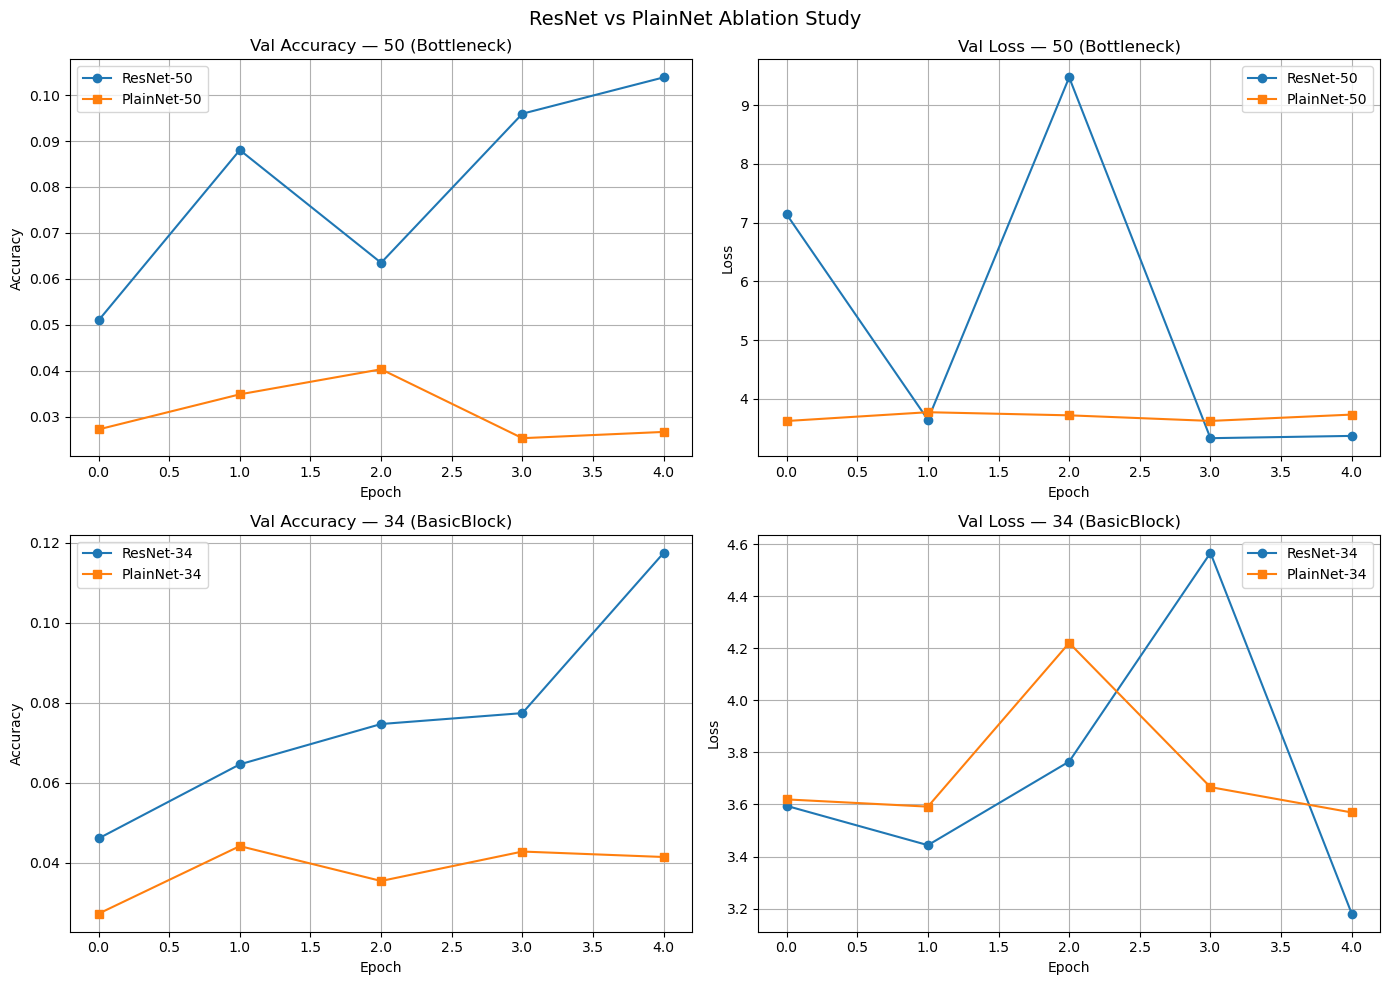

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 50층 (Bottleneck) ────────────────────────────────────
# Validation Accuracy 비교
axes[0][0].plot(h_resnet50["val_acc"],  label="ResNet-50",   marker='o')
axes[0][0].plot(h_plain50["val_acc"],   label="PlainNet-50", marker='s')
axes[0][0].set_title("Val Accuracy — 50 (Bottleneck)")
axes[0][0].set_xlabel("Epoch"); axes[0][0].set_ylabel("Accuracy")
axes[0][0].legend(); axes[0][0].grid(True)

# Validation Loss 비교
axes[0][1].plot(h_resnet50["val_loss"], label="ResNet-50",   marker='o')
axes[0][1].plot(h_plain50["val_loss"],  label="PlainNet-50", marker='s')
axes[0][1].set_title("Val Loss — 50 (Bottleneck)")
axes[0][1].set_xlabel("Epoch"); axes[0][1].set_ylabel("Loss")
axes[0][1].legend(); axes[0][1].grid(True)

# ── 34층 (BasicBlock) ────────────────────────────────────
# Validation Accuracy 비교
axes[1][0].plot(h_resnet34["val_acc"],  label="ResNet-34",   marker='o')
axes[1][0].plot(h_plain34["val_acc"],   label="PlainNet-34", marker='s')
axes[1][0].set_title("Val Accuracy — 34 (BasicBlock)")
axes[1][0].set_xlabel("Epoch"); axes[1][0].set_ylabel("Accuracy")
axes[1][0].legend(); axes[1][0].grid(True)

# Validation Loss 비교
axes[1][1].plot(h_resnet34["val_loss"], label="ResNet-34",   marker='o')
axes[1][1].plot(h_plain34["val_loss"],  label="PlainNet-34", marker='s')
axes[1][1].set_title("Val Loss — 34 (BasicBlock)")
axes[1][1].set_xlabel("Epoch"); axes[1][1].set_ylabel("Loss")
axes[1][1].legend(); axes[1][1].grid(True)

plt.suptitle("ResNet vs PlainNet Ablation Study", fontsize=14)
plt.tight_layout()
plt.savefig("ablation_result.png", dpi=150)  # 그래프 이미지 저장
plt.show()

### 5-2. Ablation Study 결과표

각 모델의 Best Validation Accuracy를 표로 정리합니다.

In [10]:
# 각 모델의 best validation accuracy 추출 (% 단위로 변환)
best_resnet34  = round(max(h_resnet34["val_acc"]) * 100, 2)
best_plain34   = round(max(h_plain34["val_acc"])  * 100, 2)
best_resnet50  = round(max(h_resnet50["val_acc"]) * 100, 2)
best_plain50   = round(max(h_plain50["val_acc"])  * 100, 2)

# 논문 스타일 결과표 생성
# 행: 레이어 수(34/50), 열: plain vs ResNet
data = {
    "plain":  [best_plain34,  best_plain50],
    "ResNet": [best_resnet34, best_resnet50],
}
df = pd.DataFrame(data, index=["34 layers", "50 layers"])

# 표 스타일 적용 (논문 테이블 형식)
df.style\
  .format("{:.2f}")\
  .set_properties(**{"text-align": "center"})\
  .set_table_styles([
      {"selector": "th",
       "props": [("text-align", "center")]},
      {"selector": "thead tr th",
       "props": [("border-top", "2px solid black"),
                 ("border-bottom", "1px solid black")]},
      {"selector": "tbody tr:last-child td",
       "props": [("border-bottom", "2px solid black")]},
  ])

,plain,ResNet
34 layers,4.42,11.75
50 layers,4.03,10.38


## 회고

### RuntimeError: expected input to have 256 channels, but got 1024 channels → expansion 반영 누락 버그 수정
Bus error: insufficient shared memory → num_workers=2 → num_workers=0 으로 해결